862 image with 7 esp and 3 k

In [1]:
CSV_PATH = "../results/all_diff_pert_diff_eps/combined_results.csv"

In [2]:
import numpy as np

import pandas as pd
df = pd.read_csv(CSV_PATH)
# numeric safety
df["eps"] = pd.to_numeric(df["eps"], errors="coerce")
df["k"]   = pd.to_numeric(df["k"], errors="coerce")
df["lb_minus_rhs"] = pd.to_numeric(df["lb_minus_rhs"], errors="coerce")

# make sure domains_visited exists
assert "domains_visited" in df.columns

# BnB flag
df["bnb_entered"] = df["domains_visited"] > 0

# result mapping
RESULT_RENAME = {
    "sat True": "Unsafe (counterexample)",
    "unsat False": "Safe (proved)",
    "timeout False": "Timeout / Unknown",
    "error": "Error",
    "sat False": "Unsafe (counterexample with BnB)",
}

df["result_label"] = df["result"].map(RESULT_RENAME).fillna(df["result"])

df["glb_status"] = np.where(
    np.isfinite(df["lb_minus_rhs"]),
    "Finite lower bound",
    "Lower bound = -inf"
)

summary = (
    df
    .groupby(["result_label", "bnb_entered", "glb_status"])
    .size()
    .reset_index(name="Count")
)

summary

/var/folders/fr/3yg6c3f55w58dtlsnjcqjmth0000gq/T/ipykernel_31807/1996549091.py:4: DtypeWarning: Columns (14,15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


,result_label,bnb_entered,glb_status,Count
0,Error,False,Lower bound = -inf,24
1,Safe (proved),False,Finite lower bound,846
2,Timeout / Unknown,True,Finite lower bound,3
3,Unsafe (counterexample with BnB),False,Finite lower bound,17
4,Unsafe (counterexample with BnB),False,Lower bound = -inf,518
5,Unsafe (counterexample),False,Lower bound = -inf,6166


In [3]:
import pandas as pd

df["eps"] = pd.to_numeric(df["eps"], errors="coerce")
df["k"]   = pd.to_numeric(df["k"], errors="coerce")
df["result"] = df["result"].astype(str)


summary = (
    df
    .groupby(["eps", "k", "result"])
    .size()
    .reset_index(name="Count")
)


tables_per_eps = {}

for eps, dfe in summary.groupby("eps"):
    table = (
        dfe
        .pivot_table(
            index="k",
            columns="result",
            values="Count",
            fill_value=0
        )
        .reset_index()
        .sort_values("k")
    )

    # Rename columns for readability
    table = table.rename(columns={
        "sat True": "Unsafe (counterexample)",
        "unsat False": "Safe (proved)",
        "timeout False": "Timeout / Unknown",
        "error" : "Error",
        "sat False": "Unsafe Counterexample with BnB"

    })

    tables_per_eps[eps] = table



from IPython.display import display, Markdown

for eps, table in tables_per_eps.items():
    display(Markdown(f"### ε = {eps}"))
    display(table)

### ε = 0.0001

result,k,Error,nan,Unsafe Counterexample with BnB,Unsafe (counterexample),Timeout / Unknown,Safe (proved)
0,20,0.0,5624.0,23.0,235.0,1.0,151.0
1,40,3.0,5690.0,23.0,249.0,0.0,69.0
2,50,2.0,5715.0,23.0,253.0,0.0,41.0


### ε = 0.0003

result,k,Error,nan,Unsafe Counterexample with BnB,Unsafe (counterexample),Safe (proved)
0,20,3.0,5719.0,23.0,261.0,28.0
1,40,1.0,5715.0,23.0,277.0,18.0
2,50,0.0,5629.0,26.0,379.0,0.0


### ε = 0.0005

...

result,k,Error,nan,Unsafe Counterexample with BnB,Unsafe (counterexample),Safe (proved)
0,20,0.0,5612.0,33.0,389.0,0.0
1,40,1.0,5583.0,33.0,417.0,0.0
2,50,3.0,5611.0,20.0,240.0,160.0


### ε = 0.005

result,k,Error,nan,Unsafe Counterexample with BnB,Unsafe (counterexample),Safe (proved)
0,20,0.0,5716.0,20.0,244.0,54.0
1,40,1.0,5729.0,20.0,251.0,33.0
2,50,1.0,5735.0,20.0,258.0,20.0


### ε = 0.01

result,k,Error,nan,Unsafe Counterexample with BnB,Unsafe (counterexample),Safe (proved)
0,20,2.0,5727.0,20.0,274.0,11.0
1,40,1.0,5631.0,20.0,382.0,0.0
2,50,0.0,5576.0,22.0,436.0,0.0


In [5]:
import pandas as pd
GROUP_COL = "image"             # or "instance_id"

# ---- 1) Load + normalize
df = pd.read_csv(CSV_PATH)

for c in ["tag", GROUP_COL]:
    df[c] = df[c].astype(str).str.strip()

# (optional) make tag comparisons case-insensitive
df["tag_norm"] = df["tag"].str.lower()

# ---- 2) Define the exact expected 12 tags per label
# Edit this list to match your REAL tag strings exactly.
EXPECTED_TAGS = [
    # 4 globals (example: 2 eps * 2 k, etc.)  <-- replace with your real 12
    "n01440764_tench_global",
    "n01440764_tench_sego_fixmask",
    "n01440764_tench_sego_fixnonmask",
    # ... add the remaining 9 ...
]

# If your tags include the label prefix (like n01440764_tench_*), the above won't work globally.
# Usually you want expected "suffixes" instead, e.g.:
#   ["global", "seg0_fixmask", "seg0_fixnonmask", ...]
# Then check by pattern.
#
# If you truly mean "12 rows per label" regardless of exact names,
# you can skip EXPECTED_TAGS entirely and just count rows (see below).

# ---- 3) Basic check: exactly 12 rows per label
counts = df.groupby(GROUP_COL).size().rename("n_rows")
bad_count = counts[counts != 12].reset_index()

print("Labels with row-count != 12:")
print(bad_count if len(bad_count) else "None ✅")

# ---- 4) Stronger check: per label, check missing/extra tags vs expected
# If you DON'T want this, you can delete this whole section.
expected_set = set([t.strip().lower() for t in EXPECTED_TAGS])

def tag_set_for_group(g: pd.DataFrame):
    return set(g["tag_norm"].tolist())

rows = []
for label, g in df.groupby(GROUP_COL):
    got = tag_set_for_group(g)
    missing = sorted(list(expected_set - got))
    extra = sorted(list(got - expected_set))
    rows.append({
        GROUP_COL: label,
        "n_rows": len(g),
        "missing_tags": missing,
        "extra_tags": extra,
        "complete_12_expected": (len(g) == 12) and (len(missing) == 0) and (len(extra) == 0),
    })

coverage = pd.DataFrame(rows).sort_values(["complete_12_expected", "n_rows", GROUP_COL])

print("\nCoverage report (first 30 rows):")
print(coverage.head(30))

print("\nIncomplete labels:")
print(coverage[coverage["complete_12_expected"] == False][[GROUP_COL, "n_rows", "missing_tags", "extra_tags"]])

Labels with row-count != 12:
                           image  n_rows
0                n01440764_tench     147
1             n01443537_goldfish     147
2    n01484850_great_white_shark     147
3          n01491361_tiger_shark     147
4         n01496331_electric_ray     147
..                           ...     ...
857          n13040303_stinkhorn     147
858          n13044778_earthstar     147
859   n13052670_hen-of-the-woods     147
860             n13054560_bolete     147
861      n15075141_toilet_tissue     147

[862 rows x 2 columns]

Coverage report (first 30 rows):
                                 image  n_rows  \
0                      n01440764_tench     147   
1                   n01443537_goldfish     147   
2          n01484850_great_white_shark     147   
3                n01491361_tiger_shark     147   
4               n01496331_electric_ray     147   
5                       n01514668_cock     147   
6                        n01514859_hen     147   
7                    

/var/folders/fr/3yg6c3f55w58dtlsnjcqjmth0000gq/T/ipykernel_31807/2819197529.py:5: DtypeWarning: Columns (14,15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


In [64]:
import numpy as np

# numeric safety
df["eps"] = pd.to_numeric(df["eps"], errors="coerce")
df["k"]   = pd.to_numeric(df["k"], errors="coerce")
df["lb_minus_rhs"] = pd.to_numeric(df["lb_minus_rhs"], errors="coerce")

# make sure domains_visited exists
assert "domains_visited" in df.columns

# BnB flag
df["bnb_entered"] = df["domains_visited"] > 0

# result mapping
RESULT_RENAME = {
    "sat True": "Unsafe (counterexample)",
    "unsat False": "Safe (proved)",
    "timeout False": "Timeout / Unknown",
    "error": "Error",
    "sat False": "Unsafe (counterexample with BnB)",
}

df["result_label"] = df["result"].map(RESULT_RENAME).fillna(df["result"])

df["glb_status"] = np.where(
    np.isfinite(df["lb_minus_rhs"]),
    "Finite lower bound",
    "Lower bound = -inf"
)

summary = (
    df
    .groupby(["result_label", "bnb_entered", "glb_status"])
    .size()
    .reset_index(name="Count")
)

summary

summary

,result_label,bnb_entered,glb_status,Count
0,Error,False,Lower bound = -inf,24
1,Safe (proved),False,Finite lower bound,846
2,Timeout / Unknown,True,Finite lower bound,3
3,Unsafe (counterexample with BnB),False,Finite lower bound,17
4,Unsafe (counterexample with BnB),False,Lower bound = -inf,518
5,Unsafe (counterexample),False,Lower bound = -inf,6166


In [63]:
# Make sure it's numeric
df["domains_visited"] = pd.to_numeric(df["domains_visited"], errors="coerce")

# Filter rows
df_bnb = df[df["domains_visited"] > 0]

df_bnb

,instance_id,image,tag,is_global,segment_index,eps,k,score,bbox,num_changed,...,vnnlib,timeout,result,lb_minus_rhs,domains_visited,bab_time,all_time,init_unstable,bnb_entered,result_label
3959,3960,n01644900_tailed_frog,n01644900_tailed_frog_seg2_fixnonmask,False,2,0.0007,50,0.497459,"[0, 1, 223, 203]",150,...,vnnlib/n01860187_black_swan_seg2_fixmask_eps_0...,1200.0,timeout False,-2.598585,3.0,1973.926614,1983.483679,0.0,True,Timeout / Unknown
4103,4104,n01665541_leatherback_turtle,n01665541_leatherback_turtle_seg2_fixnonmask,False,2,0.0005,50,0.496806,"[0, 41, 223, 182]",150,...,vnnlib/n01873310_platypus_seg2_fixmask_eps_0.0...,1200.0,timeout False,-0.000505,3.0,1779.134633,1789.679860,0.0,True,Timeout / Unknown
6993,6994,n01744401_rock_python,n01744401_rock_python_seg1_fixnonmask,False,1,0.0001,20,0.689614,"[0, 0, 223, 223]",60,...,vnnlib/n02089973_English_foxhound_seg2_fixmask...,1200.0,timeout False,-0.002233,3.0,1924.150747,1938.943943,0.0,True,Timeout / Unknown


**Global vs Mask / Non-mask**

In [49]:
## Load and prepare paired table
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 9.5,
    "axes.labelsize": 9,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
})

df = pd.read_csv(CSV_PATH, low_memory=False)

TIME_COL = "all_time" if "all_time" in df.columns else "bab_time"
print("TIME_COL:", TIME_COL)

def eps_from_vnnlib(v):
    if not isinstance(v, str):
        return np.nan
    m = re.search(r"eps[_=]?([0-9]*\.?[0-9]+)", v)
    return float(m.group(1)) if m else np.nan

def variant_from_vnnlib(v):
    if not isinstance(v, str):
        return None
    s = v.lower()
    if "seg1" in s or "seg2" in s:
        return None
    if "global" in s:
        return "Global"
    if "seg0" in s:
        # Non-mask patterns first (customize if your naming differs)
        if "nomask" in s or "nonmask" in s or "no_mask" in s or "non_mask" in s or "free" in s:
            return "Seg-0 (Non-mask)"
        if "fixmask" in s or "mask" in s:
            return "Seg-0 (Mask)"
        return "Seg-0 (Unknown)"
    return None

df["eps_vnn"] = df["vnnlib"].apply(eps_from_vnnlib)
df["variant"] = df["vnnlib"].apply(variant_from_vnnlib)

keep = ["Global", "Seg-0 (Mask)", "Seg-0 (Non-mask)"]
d = df[df["variant"].isin(keep)].copy()

# Required columns
need_cols = ["image", "k", "eps_vnn", TIME_COL]
for c in need_cols:
    assert c in d.columns, f"Missing required column: {c}"

# Optional columns (for annotations)
if "percent_changed" not in d.columns:
    d["percent_changed"] = np.nan
if "score" not in d.columns:
    d["score"] = np.nan

# Clean numeric
d["k"] = pd.to_numeric(d["k"], errors="coerce")
d["eps_vnn"] = pd.to_numeric(d["eps_vnn"], errors="coerce")
d[TIME_COL] = pd.to_numeric(d[TIME_COL], errors="coerce")
d["percent_changed"] = pd.to_numeric(d["percent_changed"], errors="coerce")
d["score"] = pd.to_numeric(d["score"], errors="coerce")

d = d.dropna(subset=["image", "k", "eps_vnn", TIME_COL])
d = d[(d["k"] > 0) & (d[TIME_COL] > 0)].copy()

pair_keys = ["image", "eps_vnn", "k"]

# Build paired wide table for time, percent_changed, score
time_wide = (
    d.pivot_table(index=pair_keys, columns="variant", values=TIME_COL, aggfunc="mean")
     .reset_index()
)
pct_wide = (
    d.pivot_table(index=pair_keys, columns="variant", values="percent_changed", aggfunc="mean")
     .reset_index()
)
score_wide = (
    d.pivot_table(index=pair_keys, columns="variant", values="score", aggfunc="mean")
     .reset_index()
)

paired = time_wide.merge(pct_wide, on=pair_keys, suffixes=("", "_pct"))
paired = paired.merge(score_wide, on=pair_keys, suffixes=("", "_score"))

# Keep only rows where all three variants exist (so bars are "corresponding")
all3 = paired.dropna(subset=["Global", "Seg-0 (Mask)", "Seg-0 (Non-mask)"]).copy()

print("Paired rows (all 3 variants present):", len(all3))
display(all3.head())
print("Unique eps:", sorted(all3["eps_vnn"].unique())[:10], "...  total:", all3["eps_vnn"].nunique())


TIME_COL: all_time
Paired rows (all 3 variants present): 553


variant,image,eps_vnn,k,Global,Seg-0 (Mask),Seg-0 (Non-mask),Global_pct,Seg-0 (Mask)_pct,Seg-0 (Non-mask)_pct,Global_score,Seg-0 (Mask)_score,Seg-0 (Non-mask)_score
0,n01440764_tench,0.0001,20,11.847602,10.381226,664.844480,0.039860,0.039860,0.039860,NaN,0.475153,0.943832
2,n01440764_tench,0.0001,50,9.122086,731.918861,12.707252,0.099649,0.099649,0.099649,0.943832,0.945320,NaN
4,n01440764_tench,0.0003,40,11.594526,10.528398,704.429736,0.079719,0.079719,0.079719,NaN,0.475153,0.943832
15,n01440764_tench,0.0050,20,8.884467,9.954116,10.450829,0.039860,0.039860,0.039860,0.945320,NaN,0.475153
16,n01440764_tench,0.0050,40,10.381485,8.934021,11.773239,0.079719,0.079719,0.079719,0.943832,0.945320,NaN


Unique eps: [np.float64(0.0001), np.float64(0.0003), np.float64(0.0005), np.float64(0.0007), np.float64(0.001), np.float64(0.005), np.float64(0.01)] ...  total: 7


In [50]:
import math

def _eps_grid(eps_values, max_cols=4):
    n = len(eps_values)
    cols = min(max_cols, max(1, n))
    rows = math.ceil(n / cols)
    return rows, cols

def _annotate_bar(ax, x, y, txt):
    ax.text(x, y, txt, ha="center", va="bottom", fontsize=7.5, rotation=0)

def _sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(len(x))

eps_values = sorted(all3["eps_vnn"].unique())


## Figure 1: Mean runtime

Each subplot corresponds to a fixed ε and shows three bars:
- Global
- Seg-0 (Non-mask)
- Seg-0 (Mask)

Bars show **mean runtime**.
Error bars show **SEM**.
Bar annotations include mean **percent_changed** and (for seg variants) mean **mask score**.


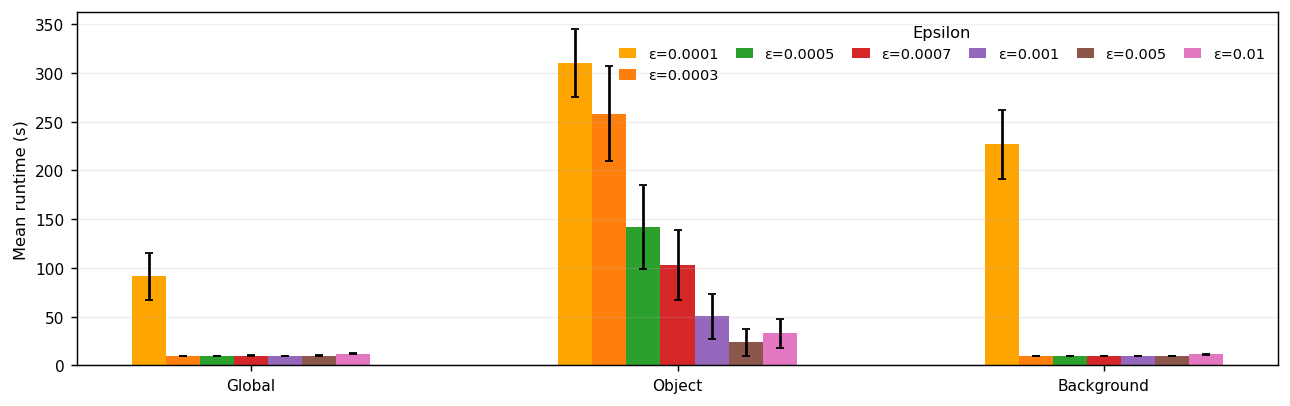

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# ----- CONFIG -----
variants = ["Global", "Seg-0 (Non-mask)", "Seg-0 (Mask)"]
group_labels = ["Global", "Object", "Background"]  # rename for display

# Ensure eps are sorted and stable
eps_values_sorted = sorted(eps_values)

# Color per epsilon (you can edit this mapping)
# Example: force eps=0.0001 to be orange
eps_color = {}
for e in eps_values_sorted:
    eps_color[e] = None  # placeholder (we'll fill below)

# Pick a default palette from matplotlib, then override 0.0001
palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, e in enumerate(eps_values_sorted):
    eps_color[e] = palette[i % len(palette)]

# Override: eps=0.0001 -> orange (if present)
for e in eps_values_sorted:
    if np.isclose(e, 1e-4):
        eps_color[e] = "orange"

# ----- BUILD DATA: mean runtime per (variant, eps) -----
# result matrix shape: (n_variants, n_eps)
means = np.full((len(variants), len(eps_values_sorted)), np.nan, dtype=float)
sems  = np.full((len(variants), len(eps_values_sorted)), np.nan, dtype=float)

for vi, v in enumerate(variants):
    for ei, eps in enumerate(eps_values_sorted):
        sub = all3[all3["eps_vnn"] == eps]
        vals = sub[v].values
        means[vi, ei] = np.nanmean(vals)
        sems[vi, ei]  = _sem(vals)

# ----- PLOT: grouped bars (3 groups), tiny bars per eps in each group -----
fig, ax = plt.subplots(figsize=(10, 3.2))

n_groups = len(variants)
n_eps = len(eps_values_sorted)

group_x = np.arange(n_groups)

# "Tiny bars": make width small, and distribute within each group
bar_width = min(0.08, 0.75 / max(n_eps, 1))   # small, auto-adjust
total_span = n_eps * bar_width
start_offset = -0.5 * total_span + 0.5 * bar_width

for ei, eps in enumerate(eps_values_sorted):
    x = group_x + start_offset + ei * bar_width
    ax.bar(
        x,
        means[:, ei],
        width=bar_width,
        yerr=sems[:, ei],
        capsize=2,
        label=f"ε={eps:g}",
        color=eps_color[eps]
    )

ax.set_xticks(group_x)
ax.set_xticklabels(group_labels, rotation=0)
ax.set_ylabel("Mean runtime (s)")
ax.grid(True, axis="y", alpha=0.2)

# Cleaner legend (eps colors)
ax.legend(
    title="Epsilon",
    ncol=min(6, n_eps),
    fontsize=8,
    title_fontsize=9,
    frameon=False,
    handlelength=1.2,
    columnspacing=1.2
)

plt.tight_layout()
plt.show()

In [52]:
import numpy as np
import pandas as pd

# Keep ONLY the exact labels you care about, everything else -> "other"
CANON = ["sat True", "sat False", "unsat False", "timeout False"]

def normalize_result_exact(r):
    s = str(r).strip()
    # make spacing consistent
    s = " ".join(s.split())
    # normalize case to match your list
    s_l = s.lower()
    # map to canonical lowercase labels
    if s_l in [c.lower() for c in CANON]:
        # return exactly as CANON casing
        # (we’ll use lowercase canonical consistently)
        return s_l
    return "other"

d_res = d.copy()
d_res["result_exact"] = d_res["result"].apply(normalize_result_exact)

pair_keys = ["image", "eps_vnn", "k"]
variants = ["Global", "Seg-0 (Non-mask)", "Seg-0 (Mask)"]

# Pivot to wide: one result per (image, eps, k) per variant
res_wide = (
    d_res[d_res["variant"].isin(variants)]
    .pivot_table(
        index=pair_keys,
        columns="variant",
        values="result_exact",
        aggfunc=lambda x: x.iloc[0] if len(x) else np.nan,
    )
    .reset_index()
)

# Keep only fully corresponding triples (all 3 present)
res_all3 = res_wide.dropna(subset=variants).copy()

print("Paired outcome rows (all 3 variants present):", len(res_all3))
display(res_all3.head(10))
print("Unique labels present:", pd.unique(d_res["result_exact"]))

Paired outcome rows (all 3 variants present): 553


variant,image,eps_vnn,k,Global,Seg-0 (Mask),Seg-0 (Non-mask)
0,n01440764_tench,0.0001,20,sat true,sat true,unsat false
2,n01440764_tench,0.0001,50,sat true,unsat false,sat false
4,n01440764_tench,0.0003,40,sat true,sat true,unsat false
15,n01440764_tench,0.0050,20,sat true,sat true,sat true
16,n01440764_tench,0.0050,40,sat true,sat true,sat false
19,n01440764_tench,0.0100,40,sat true,sat true,sat true
20,n01440764_tench,0.0100,50,sat true,sat true,sat false
28,n01443537_goldfish,0.0005,40,sat true,sat true,unsat false
32,n01443537_goldfish,0.0007,50,sat true,sat true,unsat false
36,n01443537_goldfish,0.0050,20,sat true,sat true,sat false


Unique labels present: ['sat true' 'sat false' 'unsat false']


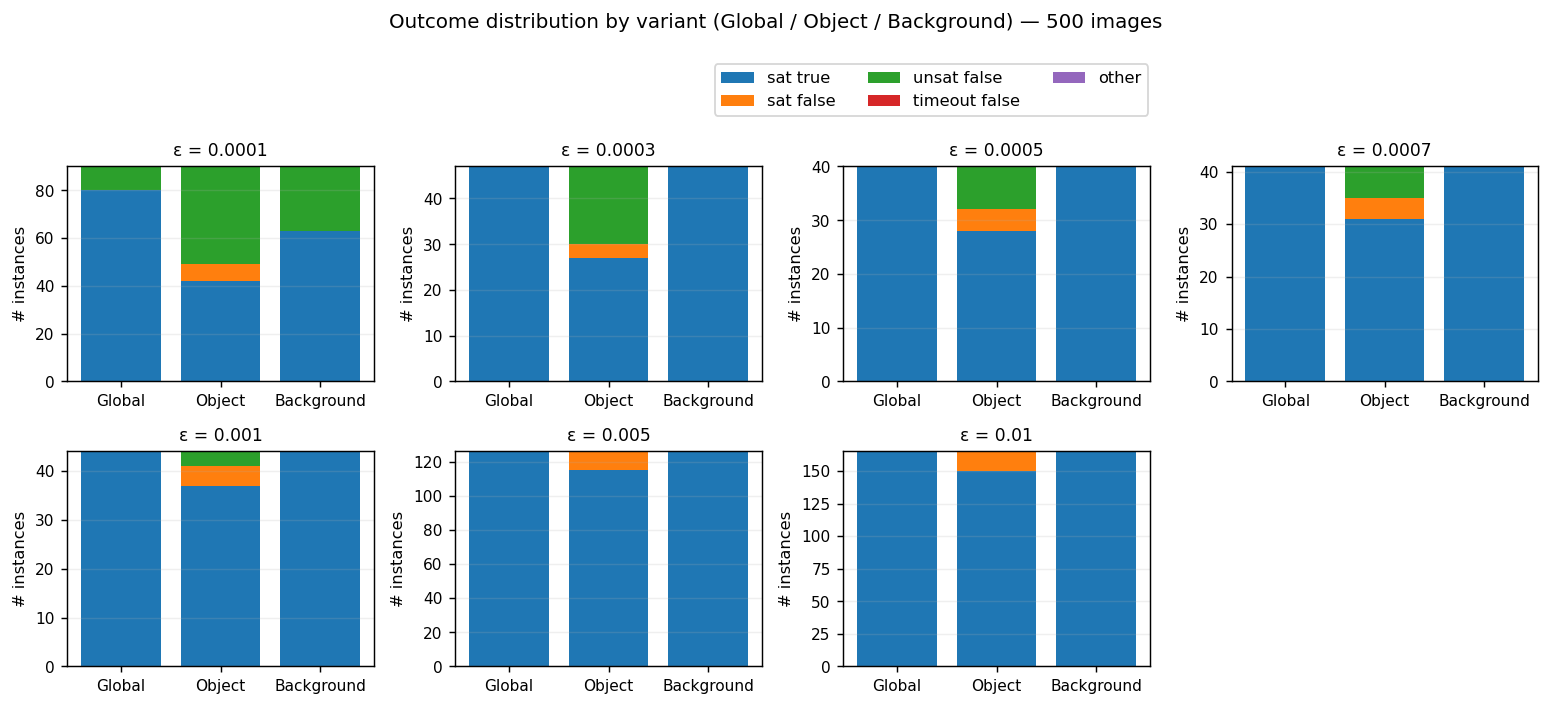

In [53]:
import math
import matplotlib.pyplot as plt
import numpy as np

order = ["sat true", "sat false", "unsat false", "timeout false", "other"]

eps_values = sorted(res_all3["eps_vnn"].unique())
max_cols = 4
cols = min(max_cols, max(1, len(eps_values)))
rows = math.ceil(len(eps_values) / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 3.0, rows * 2.4),
    squeeze=False
)

for idx, eps in enumerate(eps_values):
    r, c = divmod(idx, cols)
    ax = axes[r][c]
    sub = res_all3[res_all3["eps_vnn"] == eps]

    x = np.arange(len(variants))
    bottom = np.zeros(len(variants), dtype=float)

    for lab in order:
        vals = np.array([(sub[v] == lab).sum() for v in variants], dtype=float)
        ax.bar(x, vals, bottom=bottom, label=lab)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(["Global", "Object", "Background"])
    ax.set_title(f"ε = {eps:g}")
    ax.set_ylabel("# instances")
    ax.grid(True, axis="y", alpha=0.2)

# Hide unused axes
for j in range(len(eps_values), rows * cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")

# -----------------------------
# Legend (moved slightly right)
# -----------------------------
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.6, 1.05),  # adjust left/right if needed
    ncol=3,
    frameon=True,
    fontsize=9,
)

# -----------------------------
# Figure-level title (500 images)
# -----------------------------
fig.suptitle(
    "Outcome distribution by variant (Global / Object / Background) — 500 images",
    y=1.12,
    fontsize=11,
)

plt.tight_layout()
plt.show()

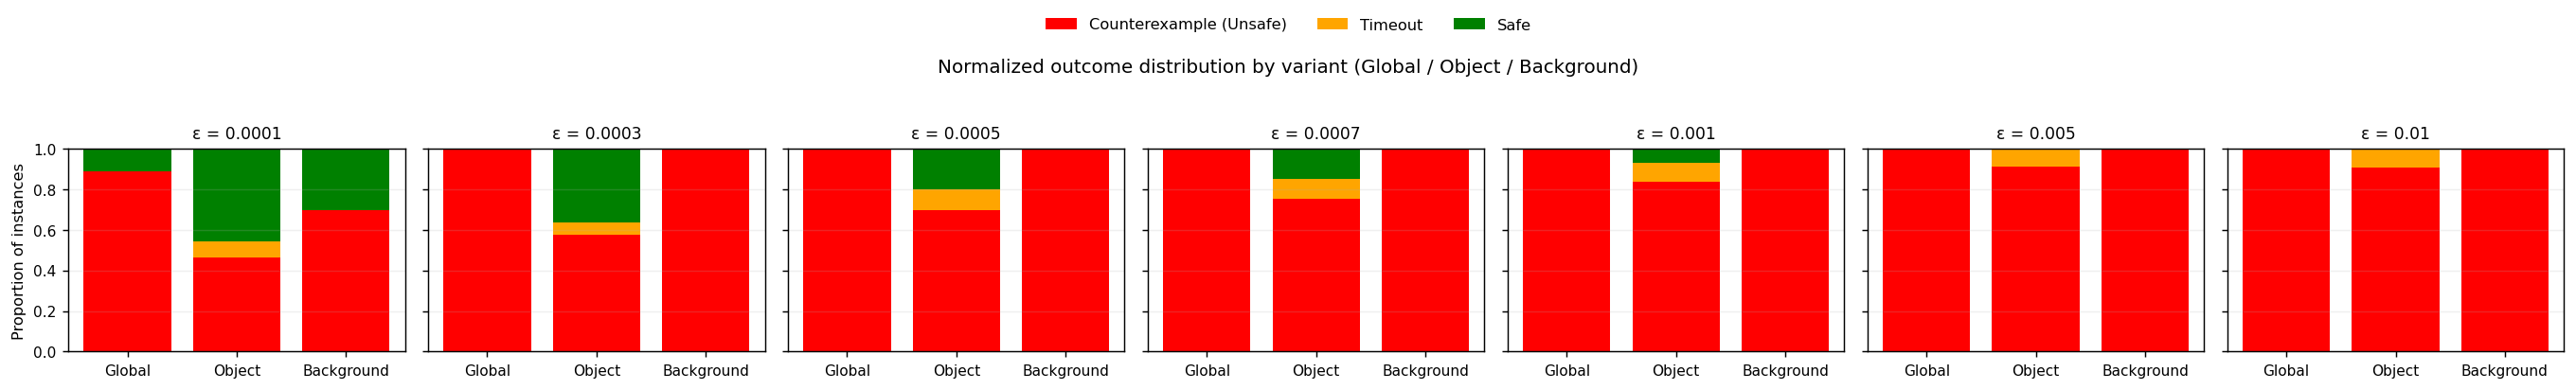

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Map raw labels -> 3 buckets
# -----------------------------
def normalize_outcome(x: str) -> str:
    s = str(x).strip().lower()
    if s == "sat true":
        return "Counterexample (Unsafe)"
    if s == "unsat false":
        return "Safe"
    return "Timeout"

bucket_order = ["Counterexample (Unsafe)", "Timeout", "Safe"]
color_map = {
    "Counterexample (Unsafe)": "red",
    "Timeout": "orange",
    "Safe": "green",
}

eps_values = sorted(res_all3["eps_vnn"].unique())

# force all eps plots in one row
cols = len(eps_values)
rows = 1

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 3.0, 2.6),
    squeeze=False,
    sharey=True
)

for idx, eps in enumerate(eps_values):
    ax = axes[0][idx]
    sub = res_all3[res_all3["eps_vnn"] == eps]

    x = np.arange(len(variants))
    bottom = np.zeros(len(variants), dtype=float)

    # total per variant (for normalization)
    totals = np.array([len(sub[v]) for v in variants], dtype=float)
    totals[totals == 0] = 1.0  # safety guard

    for lab in bucket_order:
        counts = np.array(
            [(sub[v].apply(normalize_outcome) == lab).sum() for v in variants],
            dtype=float
        )
        vals = counts / totals   # 🔹 NORMALIZATION 🔹
        ax.bar(x, vals, bottom=bottom, color=color_map[lab])
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(["Global", "Object", "Background"])
    ax.set_title(f"ε = {eps:g}")
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", alpha=0.2)

axes[0][0].set_ylabel("Proportion of instances")

fig.suptitle(
    "Normalized outcome distribution by variant (Global / Object / Background)",
    y=1.05,
    fontsize=11,
)

from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor="red", label="Counterexample (Unsafe)"),
    Patch(facecolor="orange", label="Timeout"),
    Patch(facecolor="green", label="Safe"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.22)
)

plt.tight_layout()
plt.show()